In [1]:
from sklearn import datasets

data_breast_cancer = datasets.load_breast_cancer(as_frame=True)
print(data_breast_cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [2]:
data_iris = datasets.load_iris(as_frame=True)
print(data_iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [3]:
from sklearn.model_selection import train_test_split

X = data_breast_cancer.data[['mean area', 'mean smoothness']]
y = data_breast_cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import pickle

svm_unscaled = LinearSVC(loss="hinge")
svm_unscaled.fit(X_train, y_train)

svm_scaled = Pipeline([("scaler", StandardScaler()), ("linear_svc", LinearSVC(loss="hinge"))]) 
svm_scaled.fit(X_train, y_train)

acc_train_unscaled = accuracy_score(y_train, svm_unscaled.predict(X_train))
print(f"Accuracy zbiory uczącego bez skalowania {acc_train_unscaled}")
acc_test_unscaled = accuracy_score(y_test, svm_unscaled.predict(X_test))
print(f"Accuracy zbiory testującego bez skalowania {acc_test_unscaled}")
acc_train_scaled = accuracy_score(y_train, svm_scaled.predict(X_train))
print(f"Accuracy zbiory uczącego ze skalowaniem {acc_train_scaled}")
acc_test_scaled = accuracy_score(y_test, svm_scaled.predict(X_test))
print(f"Accuracy zbiory testującego ze skalowaniem {acc_test_scaled}")

class_acc = [acc_train_unscaled, acc_test_unscaled, acc_train_scaled, acc_test_scaled]

with open('bc_acc.pkl', 'wb') as f:
    pickle.dump(class_acc, f)

Accuracy zbiory uczącego bez skalowania 0.6307692307692307
Accuracy zbiory testującego bez skalowania 0.6140350877192983
Accuracy zbiory uczącego ze skalowaniem 0.9054945054945055
Accuracy zbiory testującego ze skalowaniem 0.8596491228070176


/home/patryk-mikos/.miniforge3/envs/ml/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [5]:
import numpy as np

X = data_iris.data[['petal length (cm)', 'petal width (cm)']]
y = (data_iris.target == 2).astype(np.int8)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [6]:
svm_unscaled = LinearSVC(loss="hinge")
svm_unscaled.fit(X_train, y_train)

svm_scaled = Pipeline([("scaler", StandardScaler()), ("linear_svc", LinearSVC(loss="hinge"))]) 
svm_scaled.fit(X_train, y_train)

acc_train_unscaled = accuracy_score(y_train, svm_unscaled.predict(X_train))
print(f"Accuracy zbiory uczącego bez skalowania {acc_train_unscaled}")
acc_test_unscaled = accuracy_score(y_test, svm_unscaled.predict(X_test))
print(f"Accuracy zbiory testującego bez skalowania {acc_test_unscaled}")
acc_train_scaled = accuracy_score(y_train, svm_scaled.predict(X_train))
print(f"Accuracy zbiory uczącego ze skalowaniem {acc_train_scaled}")
acc_test_scaled = accuracy_score(y_test, svm_scaled.predict(X_test))
print(f"Accuracy zbiory testującego ze skalowaniem {acc_test_scaled}")

class_acc = [acc_train_unscaled, acc_test_unscaled, acc_train_scaled, acc_test_scaled]

with open('iris_acc.pkl', 'wb') as f:
    pickle.dump(class_acc, f)

Accuracy zbiory uczącego bez skalowania 0.9583333333333334
Accuracy zbiory testującego bez skalowania 0.9666666666666667
Accuracy zbiory uczącego ze skalowaniem 0.9583333333333334
Accuracy zbiory testującego ze skalowaniem 0.9333333333333333


/home/patryk-mikos/.miniforge3/envs/ml/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


<Axes: xlabel='x', ylabel='y'>

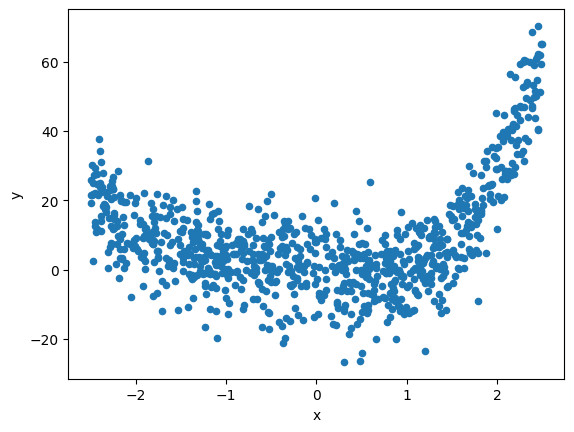

In [7]:
import pandas as pd
size = 900
X = np.random.rand(size)*5-2.5
w4, w3, w2, w1, w0 = 1, 2, 1, -4, 2
y = w4*(X**4) + w3*(X**3) + w2*(X**2) + w1*X + w0 + np.random.randn(size)*8-4
df = pd.DataFrame({'x': X, 'y': y})
df.plot.scatter(x='x',y='y')

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

In [9]:
from sklearn.svm import LinearSVR
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

linear_svr_poly = Pipeline([("poly_features", PolynomialFeatures(degree=4, include_bias=False)), ("scaler", StandardScaler()), ("linear_svr", LinearSVR())])
linear_svr_poly.fit(X_train, y_train)

mse_train_linear = mean_squared_error(y_train, linear_svr_poly.predict(X_train))
mse_test_linear = mean_squared_error(y_test, linear_svr_poly.predict(X_test))

print(f"MSE zbiór uczący: {mse_train_linear}")
print(f"MSE zbiór testowy: {mse_test_linear}")

MSE zbiór uczący: 67.71797118427565
MSE zbiór testowy: 61.09427375305998


In [10]:
from sklearn.svm import SVR

svr_poly = Pipeline([("scaler", StandardScaler()), ("svr", SVR(kernel="poly", degree=4))])
svr_poly.fit(X_train, y_train)

mse_train_svr = mean_squared_error(y_train, svr_poly.predict(X_train))
mse_test_svr = mean_squared_error(y_test, svr_poly.predict(X_test))

print(f"MSE zbiór uczący: {mse_train_svr}")
print(f"MSE zbiór testowy: {mse_test_svr}")

MSE zbiór uczący: 111.18117911542407
MSE zbiór testowy: 107.54783467409484


In [11]:
from sklearn.model_selection import GridSearchCV

X = X.reshape(-1, 1)

param_grid = {
    "svr__C" : [0.1, 1, 10],
    "svr__coef0" : [0.1, 1, 10]
}
search = GridSearchCV(svr_poly, param_grid, scoring="neg_mean_squared_error", n_jobs=-1)
search.fit(X, y)
print(f"Najlepsze parametry {search.best_params_}")

best_C = search.best_params_["svr__C"]
best_coef0 = search.best_params_["svr__coef0"]

Najlepsze parametry {'svr__C': 1, 'svr__coef0': 10}


In [12]:
from sklearn.svm import SVR

svr_poly_best = Pipeline([("scaler", StandardScaler()), ("svr", SVR(kernel="poly", degree=4, C=best_C, coef0=best_coef0))])
svr_poly_best.fit(X_train, y_train)

mse_train_svr_best = mean_squared_error(y_train, svr_poly_best.predict(X_train))
mse_test_svr_best = mean_squared_error(y_test, svr_poly_best.predict(X_test))

print(f"MSE zbiór uczący: {mse_train_svr_best}")
print(f"MSE zbiór testowy: {mse_test_svr_best}")

MSE zbiór uczący: 67.47317579023984
MSE zbiór testowy: 61.931086605823275


In [13]:
reg_mse = [mse_train_linear, mse_test_linear, mse_train_svr_best, mse_test_svr_best]

with open('reg_mse.pkl', 'wb') as f:
    pickle.dump(reg_mse, f)